# 05.2 - Linear Regression (from scratch)

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Linear regression predicts a continuous target as a linear combination of features. We implement it **from scratch** in NumPy using gradient descent, then compare to scikit-learn.

## 2. Why Does This Matter?

Linear regression is the foundation of all supervised learning. Understanding the math (hypothesis, loss, gradient) and the training loop (gradient descent) transfers to every other model.

## 3. Prerequisites

- Phase 02 (Math), Phase 03 (Statistics)

## 4. Learning Objectives

By the end of this unit, you should be able to:
- Write the hypothesis, MSE loss, and gradient for linear regression
- Implement gradient descent from scratch in NumPy
- Evaluate with MAE, MSE, RMSE, R^2
- Understand the effect of learning rate, scaling, noise, outliers

## 5. Mental Model

Model: y_hat = w0 + w1*x1 + ... + wn*xn

Loss (MSE): (1/m) * sum((y - y_hat)^2)

Gradient descent update: w = w - lr * dL/dw

We iterate: predict -> compute loss -> compute gradient -> update weights.


## 6. Generate Synthetic Data

Create data with a known linear relationship plus noise.


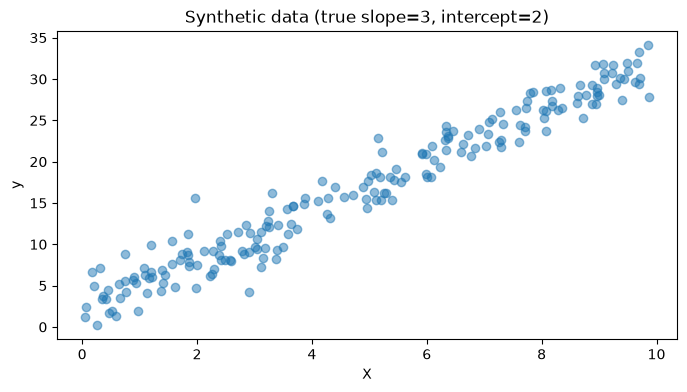

True relationship: y = 3.0*X + 2.0 + noise


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
n = 200
X = np.random.uniform(0, 10, n)
true_w = 3.0
true_b = 2.0
y = true_w * X + true_b + np.random.normal(0, 2, n)

plt.figure(figsize=(8, 4))
plt.scatter(X, y, alpha=0.5)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic data (true slope=3, intercept=2)")
plt.show()
print(f"True relationship: y = {true_w}*X + {true_b} + noise")


## 7. Implement Linear Regression from Scratch

We implement the hypothesis, MSE loss, gradient, and gradient descent.


Learned: w=2.986, b=2.202
True:    w=3.000, b=2.000
Final MSE: 3.735


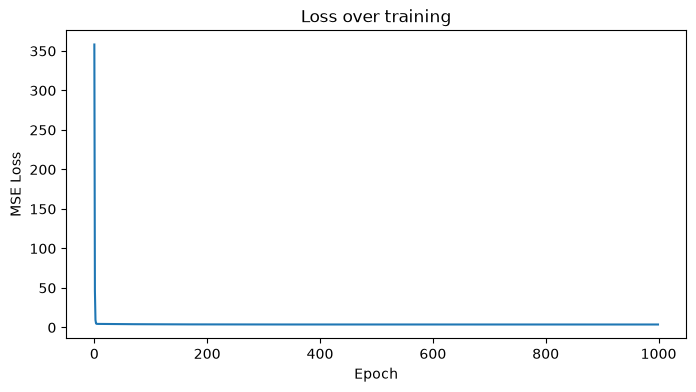

In [2]:
def predict(X, w, b):
    return w * X + b

def mse_loss(y, y_hat):
    return np.mean((y - y_hat) ** 2)

def gradients(X, y, y_hat):
    m = len(y)
    dw = (-2 / m) * np.sum(X * (y - y_hat))
    db = (-2 / m) * np.sum(y - y_hat)
    return dw, db

def gradient_descent(X, y, lr=0.01, epochs=1000):
    w, b = 0.0, 0.0
    history = []
    for i in range(epochs):
        y_hat = predict(X, w, b)
        loss = mse_loss(y, y_hat)
        dw, db = gradients(X, y, y_hat)
        w -= lr * dw
        b -= lr * db
        history.append(loss)
    return w, b, history

w, b, history = gradient_descent(X, y, lr=0.01, epochs=1000)
print(f"Learned: w={w:.3f}, b={b:.3f}")
print(f"True:    w={true_w:.3f}, b={true_b:.3f}")
print(f"Final MSE: {history[-1]:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss over training")
plt.show()


## 8. Compare to scikit-learn

Verify our from-scratch implementation matches sklearn.


In [3]:
model = LinearRegression()
model.fit(X.reshape(-1, 1), y)
print(f"sklearn: w={model.coef_[0]:.3f}, b={model.intercept_:.3f}")
print(f"Ours:    w={w:.3f}, b={b:.3f}")
print("\nThey match closely!")


sklearn: w=2.984, b=2.210
Ours:    w=2.986, b=2.202

They match closely!


## 9. Evaluation Metrics

Compute MAE, MSE, RMSE, and R^2.


In [4]:
y_hat = predict(X, w, b)
mae = mean_absolute_error(y, y_hat)
mse = mean_squared_error(y, y_hat)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_hat)

print(f"MAE:  {mae:.3f}")
print(f"MSE:  {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2:  {r2:.3f}")
print("\nR^2 close to 1 means the model explains most variance.")


MAE:  1.526
MSE:  3.735
RMSE: 1.933
R^2:  0.954

R^2 close to 1 means the model explains most variance.


## 10. Experiment: Learning Rate

Too small a learning rate converges slowly; too large diverges.


In [5]:
for lr in [0.0001, 0.01, 0.1, 1.0]:
    w_t, b_t, hist = gradient_descent(X, y, lr=lr, epochs=200)
    print(f"lr={lr}: final loss={hist[-1]:.3f}, w={w_t:.3f}")
print("\nVery small lr converges slowly; very large lr may diverge.")


lr=0.0001: final loss=30.243, w=2.373


lr=0.01: final loss=3.832, w=3.075


lr=0.1: final loss=152218504047953395830677353308548572528726794965269995268599541131529529212790404141206825915644443757645907203324886101544065940226126102283466304252963649338358216120033252537999504442578149972159912840918461500261137384447794213098497036706932041341829049031709255997694841798903563507047161921536.000, w=-374575627456970248135605651764473061606550127178503526939232069477824572035411659105445317010693488460450164796933428270955123645380079098111853592576.000


lr=1.0: final loss=nan, w=nan

Very small lr converges slowly; very large lr may diverge.


D:\CODE\complete ml\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\PC\AppData\Local\Temp\ipykernel_14244\3012141155.py:5: RuntimeWarning: overflow encountered in square
  return np.mean((y - y_hat) ** 2)
D:\CODE\complete ml\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\PC\AppData\Local\Temp\ipykernel_14244\3012141155.py:20: RuntimeWarning: invalid value encountered in scalar subtract
  w -= lr * dw


## 11. Experiment: Effect of Outliers

MSE is sensitive to outliers because errors are squared.


In [6]:
# Add an outlier
X_out = np.append(X, 9.5)
y_out = np.append(y, 100)  # extreme outlier

w_o, b_o, _ = gradient_descent(X_out, y_out, lr=0.01, epochs=1000)
print(f"Without outlier: w={w:.3f}, b={b:.3f}")
print(f"With outlier:    w={w_o:.3f}, b={b_o:.3f}")
print("\nThe outlier pulls the line toward it (MSE squares the error).")


Without outlier: w=2.986, b=2.202


With outlier:    w=3.169, b=1.656

The outlier pulls the line toward it (MSE squares the error).


## 12. Failure Case: Unscaled Features

If features have very different scales, gradient descent is slow.


In [7]:
# Feature with huge scale
X_big = X * 1000
w_b, b_b, hist_b = gradient_descent(X_big, y, lr=0.01, epochs=200)
print(f"Unscaled final loss: {hist_b[-1]:.3f}")
print(f"Scaled final loss:   {history[-1]:.3f}")
print("\nScaling features speeds up convergence dramatically.")


Unscaled final loss: nan
Scaled final loss:   3.735

Scaling features speeds up convergence dramatically.


C:\Users\PC\AppData\Local\Temp\ipykernel_14244\3012141155.py:5: RuntimeWarning: overflow encountered in square
  return np.mean((y - y_hat) ** 2)
C:\Users\PC\AppData\Local\Temp\ipykernel_14244\3012141155.py:20: RuntimeWarning: invalid value encountered in scalar subtract
  w -= lr * dw


## 13. Debugging: Common Errors

- **Learning rate too high**: loss diverges.
- **Learning rate too low**: slow convergence.
- **Unscaled features**: slow or unstable.
- **Outliers**: skew the fit.

## 14. Real-World Considerations

- Standardize features for gradient-based methods.
- Use RMSE (same units as target) for interpretability.
- Check residuals for patterns.

## 15. Common Mistakes

- Using MSE when outliers matter (use MAE or Huber).
- Not scaling features.
- Ignoring multicollinearity.

## 16. When NOT to Use

- When the relationship is highly nonlinear.
- When features are highly correlated.

## 17. Challenge

Implement linear regression with multiple features (matrix form) and verify against sklearn.


In [8]:
# Challenge: multiple linear regression from scratch (matrix form)
np.random.seed(7)
n = 300
X1 = np.random.uniform(0, 10, n)
X2 = np.random.uniform(0, 5, n)
y_m = 1.5 * X1 - 2.0 * X2 + 0.5 + np.random.normal(0, 1, n)

# Add bias column
X_mat = np.column_stack([np.ones(n), X1, X2])

# Normal equation: w = (X^T X)^-1 X^T y
w_opt = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y_m
print(f"Normal equation: intercept={w_opt[0]:.3f}, w1={w_opt[1]:.3f}, w2={w_opt[2]:.3f}")
print(f"True:            intercept=0.500, w1=1.500, w2=-2.000")

# Compare to sklearn
model_m = LinearRegression().fit(np.column_stack([X1, X2]), y_m)
print(f"sklearn:         intercept={model_m.intercept_:.3f}, w1={model_m.coef_[0]:.3f}, w2={model_m.coef_[1]:.3f}")


Normal equation: intercept=0.615, w1=1.506, w2=-2.076
True:            intercept=0.500, w1=1.500, w2=-2.000
sklearn:         intercept=0.615, w1=1.506, w2=-2.076


## Hands-On Practice

### Level 1: Basic
- Fit a linear regression with sklearn and print coefficients
- Plot the regression line over data points

### Level 2: Guided
- Compute R-squared, MAE, MSE manually and with sklearn
- Fit a model with 2 features and interpret coefficients

### Level 3: Independent
- Diagnose a linear regression: plot residuals, check assumptions
- Compare linear regression with and without polynomial features

### Level 4: Realistic
- Build a housing price predictor with feature selection and regularization
- Analyze when linear regression fails on non-linear data

### Level 5: Challenge
- Implement gradient descent for linear regression from scratch (no sklearn)



## Knowledge Check

1. What does a coefficient of 3.5 mean for a feature?
2. When does linear regression fail?
3. What is the difference between R-squared and adjusted R-squared?



## Exit Criteria

- [ ] Can fit and evaluate a linear regression model
- [ ] Can interpret coefficients and R-squared
- [ ] Can diagnose model assumptions
- [ ] Can use gradient descent to minimize loss
- [ ] Completed Level 3+ practice



## Next Step

-> Unit 05.03: Logistic Regression — classification with linear boundaries.


## Hands-On Practice

### Level 1: Basic
- Fit a linear regression with sklearn and print coefficients
- Plot the regression line over data points

### Level 2: Guided
- Compute R-squared, MAE, MSE manually and with sklearn
- Fit a model with 2 features and interpret coefficients

### Level 3: Independent
- Diagnose a linear regression: plot residuals, check assumptions
- Compare linear regression with and without polynomial features

### Level 4: Realistic
- Build a housing price predictor with feature selection and regularization
- Analyze when linear regression fails on non-linear data

### Level 5: Challenge
- Implement gradient descent for linear regression from scratch (no sklearn)



## Knowledge Check

1. What does a coefficient of 3.5 mean for a feature?
2. When does linear regression fail?
3. What is the difference between R-squared and adjusted R-squared?



## Exit Criteria

- [ ] Can fit and evaluate a linear regression model
- [ ] Can interpret coefficients and R-squared
- [ ] Can diagnose model assumptions
- [ ] Can use gradient descent to minimize loss
- [ ] Completed Level 3+ practice



## Next Step

-> Unit 05.03: Logistic Regression — classification with linear boundaries.


## Hands-On Practice

### Level 1: Basic
- Fit a linear regression with sklearn and print coefficients
- Plot the regression line over data points

### Level 2: Guided
- Compute R-squared, MAE, MSE manually and with sklearn
- Fit a model with 2 features and interpret coefficients

### Level 3: Independent
- Diagnose a linear regression: plot residuals, check assumptions
- Compare linear regression with and without polynomial features

### Level 4: Realistic
- Build a housing price predictor with feature selection and regularization
- Analyze when linear regression fails on non-linear data

### Level 5: Challenge
- Implement gradient descent for linear regression from scratch (no sklearn)



## Knowledge Check

1. What does a coefficient of 3.5 mean for a feature?
2. When does linear regression fail?
3. What is the difference between R-squared and adjusted R-squared?



## Exit Criteria

- [ ] Can fit and evaluate a linear regression model
- [ ] Can interpret coefficients and R-squared
- [ ] Can diagnose model assumptions
- [ ] Can use gradient descent to minimize loss
- [ ] Completed Level 3+ practice



## Next Step

-> Unit 05.03: Logistic Regression — classification with linear boundaries.


## 18. Closed-Book Recall

Without looking back:

1. Write the linear regression hypothesis.
2. Write the MSE loss.
3. Write the gradient descent update rule.
4. What is R^2?

## 19. Teach-Back Questions

Explain to another person:

- How gradient descent finds the best weights.
- Why outliers affect MSE more than MAE.

## 20. Summary

You implemented linear regression from scratch, compared it to sklearn, and explored learning rate, outliers, and scaling. This is the foundation for all supervised learning.

## 21. Further Experiment

- Try stochastic gradient descent (one sample at a time).
- Add L2 regularization (ridge).

## 22. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib, scikit-learn
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
